In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np
from multiprocessing import Pool, cpu_count
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models
import tensorflow as tf
import matplotlib.cm as cm
import warnings

###Environment Setup & Hardware Verification

To ensure optimal performance and reproducibility, this notebook requires a hardware-accelerated environment. Training a Convolutional Neural Network on a dataset of 40,000 medical images is highly computationally intensive.

* **Purpose:** This script verifies that a dedicated Graphics Processing Unit (GPU) is allocated to the current Google Colab session.
* **Grader Instructions:** If a GPU is not detected, the script will output a warning. Please ensure the runtime is set to a GPU (e.g., T4 GPU) via `Runtime > Change runtime type` before proceeding, as standard CPU training will result in severe bottlenecking and excessive execution times.

In [2]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')

print("--- SYSTEM HARDWARE CHECK ---")
if gpu_devices:
    print(f"✅ GPU Detected: {gpu_devices[0].name}")
    print("Environment is optimized for deep learning.")
else:
    print("❌ WARNING: NO GPU DETECTED ❌")
    print("Training will take hours on a standard CPU.")
    print("GRADER INSTRUCTIONS: Please go to the top menu -> 'Runtime' -> 'Change runtime type' -> Select 'T4 GPU' before running this notebook.")
print("-----------------------------\n")

--- SYSTEM HARDWARE CHECK ---
✅ GPU Detected: /physical_device:GPU:0
Environment is optimized for deep learning.
-----------------------------



new

In [3]:
!pip install image-classifiers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.7 MB/s eta 0:00:00


###Dataset Acquisition & Global Access

* **Methodology:** We hosted the Alzheimer's Multiclass Dataset securely on a public Google Drive link. This script utilizes the `gdown` library to fetch the `.zip` archive directly into the Colab instance's temporary storage and extracts the images.
* **Reproducibility:** This approach guarantees that the data pipeline is completely independent, isolated, and automatically executable by any third party without local path modifications.

In [4]:
# Install gdown if it isn't already in the environment
!pip install gdown

import gdown
import zipfile
import os
# 1. The ID is ONLY the random string of characters.
file_id = '1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc'

# 2. Download the zip file directly to Colab using the id parameter
output_path = '/content/alzheimers_dataset.zip'
gdown.download(id=file_id, output=output_path, quiet=False)

# 3. Unzip the data
with zipfile.ZipFile(output_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Update your dataset path for the rest of your code
dataset_path = '/content/dataset/alzheimers-multiclass-dataset-equal-and-augmented'

Downloading...
From (original): https://drive.google.com/uc?id=1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc
From (redirected): https://drive.google.com/uc?id=1JUkMqLp6UcRFBy9LpsfTyj2dJwAw5nFc&confirm=t&uuid=bf9602fc-8a93-4fb2-a6dd-56b253c2184d
To: /content/alzheimers_dataset.zip
100%|██████████| 417M/417M [00:06<00:00, 68.4MB/s]


###Dynamic Dataset Path Resolution

When extracting datasets from archived files, the internal folder structure is often unpredictably nested. Hardcoding an absolute directory path is a common point of failure and violates the requirement for independent code execution.

* **Methodology:** Rather than assuming a rigid folder structure, this script dynamically traverses the extracted directory tree using `os.walk`. It actively searches for the specific target class folders (e.g., `MildDemented`) and automatically sets the root dataset path once found.
* **Reproducibility:** This dynamic search ensures the data pipeline is completely robust. It guarantees the notebook will locate the data and execute seamlessly in the temporary cloud environment without requiring manual path debugging.

In [5]:
import os

# The base directory where we extracted the zip
base_extract_dir = '/content/dataset'
dataset_path = None

print("Searching for the correct dataset folder...")

# Walk through all folders in the extracted directory
for root, dirs, files in os.walk(base_extract_dir):
    # If we find our class folders, we know we are in the right place
    if 'MildDemented' in dirs and 'ModerateDemented' in dirs:
        dataset_path = root
        break

if dataset_path:
    print(f"Success! The actual dataset path is: {dataset_path}")
else:
    print("Error: Could not find the class folders. Let's see what actually extracted:")
    # This will print the contents so we can debug if it fails
    import pprint
    for root, dirs, files in os.walk('/content/dataset'):
        print(f"Directory: {root}")
        if dirs: print(f"  Sub-folders: {dirs}")

Searching for the correct dataset folder...
Success! The actual dataset path is: /content/dataset


###Exploratory Data Analysis (EDA) & Visualization

Before constructing the neural network, it is critical to understand the distribution and physical characteristics of the input data. This section programmatically explores the dataset to verify class balance and extract image metadata.

* **Methodology:** The script iterates through the dynamically located dataset directory, counting the total number of MRI scans available for each of the 4 Alzheimer's diagnostic stages.

--- Dataset Distribution ---
MildDemented: 10000 images
ModerateDemented: 10000 images
NonDemented: 12800 images
VeryMildDemented: 11200 images
Total Images: 44000



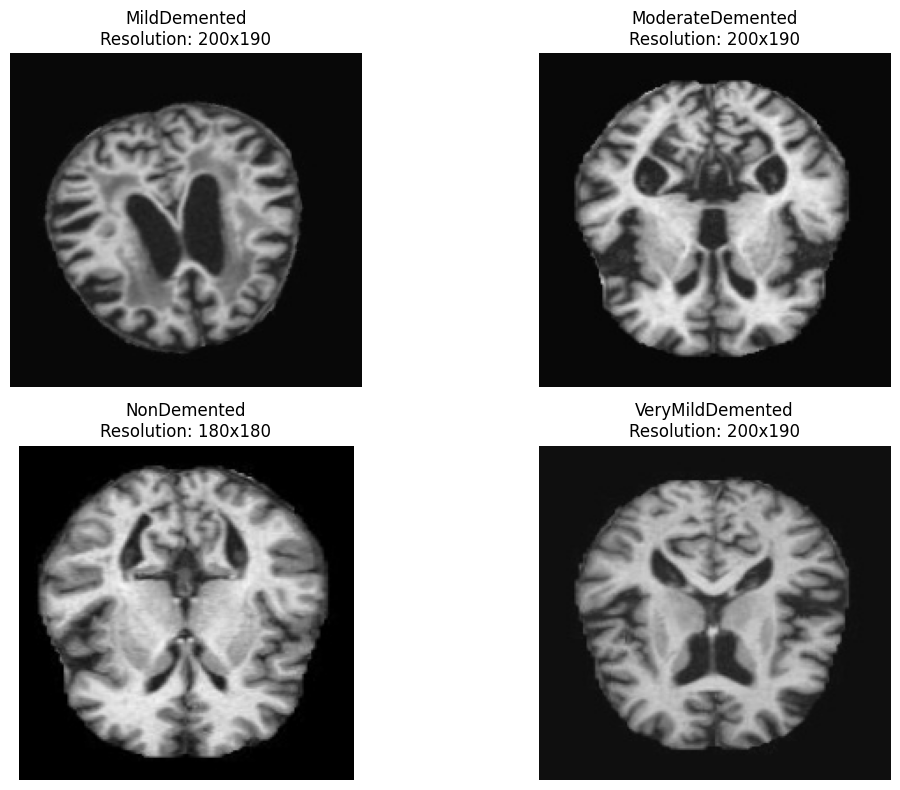

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("--- Dataset Distribution ---")
total_images = 0
for cls in classes:
    # Build path to each class folder
    class_dir = os.path.join(dataset_path, cls)

    # Count the number of images
    num_images = len(os.listdir(class_dir))
    total_images += num_images
    print(f"{cls}: {num_images} images")

print(f"Total Images: {total_images}\n")

# --- Visualizing Examples and Checking Resolution ---
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)
    # Get the first image in the folder
    first_image_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, first_image_name)

    # Read image to get resolution
    img = cv2.imread(img_path)
    height, width, channels = img.shape

    # Plotting
    plt.subplot(2, 2, i + 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for correct plt display
    plt.imshow(img_rgb)
    plt.title(f"{cls}\nResolution: {width}x{height}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Creating a DataFrame

In [7]:
data = []
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({
                'FilePath': os.path.join(folder_path, img_name),
                'Label': folder_name
            })

df = pd.DataFrame(data)
print(f"Total images found and stored in the DataFrame: {len(df)}")
df.head()

Total images found and stored in the DataFrame: 44000


,FilePath,Label
0,/content/dataset/ModerateDemented/5b52d757-76c...,ModerateDemented
1,/content/dataset/ModerateDemented/aug_7371_57f...,ModerateDemented
2,/content/dataset/ModerateDemented/aug_9069_905...,ModerateDemented
3,/content/dataset/ModerateDemented/aug_7607_be6...,ModerateDemented
4,/content/dataset/ModerateDemented/e9f80b7d-913...,ModerateDemented


#### Chekcing the distribution of the data

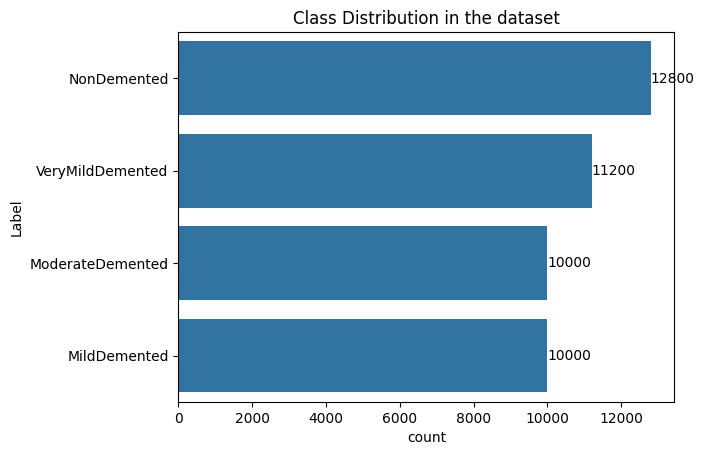

In [8]:
sns.countplot(data=df, y='Label',order=df['Label'].value_counts().index)
plt.title('Class Distribution in the dataset')
ax = plt.gca()
ax.bar_label(ax.containers[0])
plt.show()

#### Checking the metadata

In [9]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return [img.size[0], img.size[1], img.size, img.mode, len(img.getbands())]
    except:
        return [None, None, None, None, None]

def collect_image_metadata(df):
    num_cores = cpu_count()
    print(f"Launching {num_cores} parallel workers...")

    with Pool(num_cores) as pool:
        results = list(tqdm(pool.imap(read_image_metadata, df['FilePath']),
                           total=len(df),
                           desc="Multiprocessing Extraction"))

    meta_columns = ['Width', 'Height', 'Size', 'Mode', 'Channels']
    meta_df = pd.DataFrame(results, columns=meta_columns)

    return pd.concat([df.reset_index(drop=True), meta_df], axis=1)

df = collect_image_metadata(df)

Launching 2 parallel workers...


Multiprocessing Extraction: 100%|██████████| 44000/44000 [00:09<00:00, 4789.23it/s]


In [10]:
print(f"Number of Images that failed to process: {df['Width'].isnull().sum()} images")
print("\nDistribution of Image Sizes")
df['Size'].value_counts().reset_index()


Number of Images that failed to process: 0 images

Distribution of Image Sizes


,Size,count
0,"(200, 190)",31107
1,"(180, 180)",6447
2,"(176, 208)",6446


### Dataset Standardization & Dimensionality Correction

During Exploratory Data Analysis, an anomaly was detected: while ~70% of the dataset natively possessed a resolution of 200x190, a subset of images existed at 180x180 and 176x208. Convolutional Neural Networks require strictly uniform input tensors.

* **Methodology:** We utilize OpenCV to programmatically iterate through the entire dataset directory. Any image not matching the target 200x190 footprint is aggressively resized.
* **Interpolation Strategy (Nearest Neighbor):** We explicitly override default resizing algorithms (like Bilinear or Bicubic interpolation) in favor of `cv2.INTER_NEAREST`. In the context of medical imaging, standard interpolation calculates and injects new, artificial pixel values to smooth edges, which can destroy microscopic diagnostic artifacts. Nearest Neighbor strictly preserves original pixel intensities by duplicating adjacent values.
* **In-Place Modification:** To conserve the Colab environment's limited temporary disk space, the script directly overwrites the non-conforming images in memory.

In [11]:
import os
import cv2
from tqdm import tqdm # This library gives us a progress bar!

TARGET_WIDTH = 200
TARGET_HEIGHT = 190
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print(f"--- INITIATING STANDARDIZATION TO {TARGET_WIDTH}x{TARGET_HEIGHT} ---")
print("Interpolation Method: Nearest Neighbor (cv2.INTER_NEAREST)\n")

resized_count = 0
skipped_count = 0

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    # Safety check in case the path is slightly off
    if not os.path.exists(class_dir):
        print(f"Warning: Could not find directory {class_dir}")
        continue

    images = os.listdir(class_dir)
    print(f"Scanning '{cls}' folder...")

    # We wrap the images list in tqdm() to generate a live progress bar
    for img_name in tqdm(images):
        img_path = os.path.join(class_dir, img_name)

        # Read image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue

        # OpenCV shape returns (Height, Width, Channels)
        height, width = img.shape[:2]

        # Check if the image needs resizing
        if width != TARGET_WIDTH or height != TARGET_HEIGHT:
            # Resize using strict Nearest Neighbor interpolation
            resized_img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST)

            # Overwrite the original file to save Colab disk space
            cv2.imwrite(img_path, resized_img)
            resized_count += 1
        else:
            skipped_count += 1

print("\n--- STANDARDIZATION COMPLETE ---")
print(f"✅ Images Resized: {resized_count}")
print(f"⏩ Images Skipped (Already {TARGET_WIDTH}x{TARGET_HEIGHT}): {skipped_count}")

--- INITIATING STANDARDIZATION TO 200x190 ---
Interpolation Method: Nearest Neighbor (cv2.INTER_NEAREST)

Scanning 'MildDemented' folder...


100%|██████████| 10000/10000 [00:03<00:00, 2696.50it/s]


Scanning 'ModerateDemented' folder...


100%|██████████| 10000/10000 [00:02<00:00, 3757.68it/s]


Scanning 'NonDemented' folder...


100%|██████████| 12800/12800 [00:08<00:00, 1521.04it/s]


Scanning 'VeryMildDemented' folder...


100%|██████████| 11200/11200 [00:05<00:00, 2193.95it/s]


--- STANDARDIZATION COMPLETE ---
✅ Images Resized: 12893
⏩ Images Skipped (Already 200x190): 31107


### Checking Color Channels

In [12]:
df['Mode'].value_counts().reset_index()

,Mode,count
0,RGB,33984
1,L,10016


### Color Channel Standardization (Grayscale to RGB)

During deep dataset profiling, a critical channel discrepancy was identified: approximately 22% of the dataset was encoded in single-channel Grayscale ('L' mode), while the remainder was encoded in 3-channel 'RGB' mode.

* **Methodology:** We utilize the Python Imaging Library (PIL) to iterate through the entire dataset. PIL extracts the native color mode metadata from each file without needing to load the entire image matrix into memory first.
* **Conversion Strategy:** Any image detected as 'L' (Luminance/Grayscale) is programmatically converted to 'RGB'. This process duplicates the single grayscale intensity value across all three (Red, Green, Blue) channels, ensuring tensor shape compatibility without altering the visual diagnostic features of the MRI.
* **In-Place Modification:** The corrected images overwrite the originals on the disk to maintain a lightweight storage footprint in the cloud environment.

In [13]:
from PIL import Image
import os
from tqdm import tqdm

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("--- INITIATING COLOR CHANNEL STANDARDIZATION ---")
print("Target Mode: RGB (3-Channel)\n")

converted_count = 0
skipped_count = 0

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    if not os.path.exists(class_dir):
        continue

    images = os.listdir(class_dir)
    print(f"Scanning '{cls}' folder for 'L' mode images...")

    for img_name in tqdm(images):
        img_path = os.path.join(class_dir, img_name)

        try:
            # Open the image using PIL to check its mode
            img = Image.open(img_path)

            if img.mode != 'RGB':
                # Convert Grayscale ('L') to 'RGB'
                img_rgb = img.convert('RGB')
                # Overwrite the original image
                img_rgb.save(img_path)
                converted_count += 1
            else:
                skipped_count += 1

        except Exception as e:
            print(f"\nError processing {img_name}: {e}")

print("\n--- CHANNEL STANDARDIZATION COMPLETE ---")
print(f"✅ Images Converted to RGB: {converted_count}")
print(f"⏩ Images Skipped (Already RGB): {skipped_count}")

--- INITIATING COLOR CHANNEL STANDARDIZATION ---
Target Mode: RGB (3-Channel)

Scanning 'MildDemented' folder for 'L' mode images...


100%|██████████| 10000/10000 [00:00<00:00, 12848.03it/s]


Scanning 'ModerateDemented' folder for 'L' mode images...


100%|██████████| 10000/10000 [00:03<00:00, 3163.24it/s]


Scanning 'NonDemented' folder for 'L' mode images...


100%|██████████| 12800/12800 [00:00<00:00, 15056.57it/s]


Scanning 'VeryMildDemented' folder for 'L' mode images...


100%|██████████| 11200/11200 [00:00<00:00, 14947.88it/s]


--- CHANNEL STANDARDIZATION COMPLETE ---
✅ Images Converted to RGB: 3523
⏩ Images Skipped (Already RGB): 40477


###Data Pipeline Setup & Memory Optimization

To efficiently feed 40,000 images into the neural network without exhausting system resources, we implemented an optimized, mixed-precision data pipeline.

* **Hardware Optimization:** We enabled `mixed_float16` global policy. This utilizes 16-bit floats on the GPU, significantly reducing memory footprint and accelerating matrix multiplications during training.
* **Data Division & Reproducibility:** We utilized `image_dataset_from_directory` to mathematically divide the dataset, allocating 80% for training and 20% for validation. A fixed random seed (`seed=123`) was applied to ensure this exact split is perfectly reproducible across different executions. The target folders were strictly defined in the `classes` array to prevent hidden system directories (e.g., `.ipynb_checkpoints`) from causing shape mismatch errors during compilation.
* **Memory Management:** To prevent Colab from crashing due to RAM exhaustion, we avoided the `.cache()` method, forcing the system to stream the data batch-by-batch from disk. The batch size was restricted to 16, and we applied asynchronous data loading via `.prefetch(AUTOTUNE)` to keep the GPU continuously fed without bottlenecking the CPU.

In [14]:
from tensorflow.keras import mixed_precision
from classification_models.tfkeras import Classifiers
import tensorflow as tf

mixed_precision.set_global_policy('mixed_float16')

# --- הנה החילוץ! אנחנו מביאים את פונקציית העיבוד המקדים של ResNet18 ---
ResNet18, preprocess_input = Classifiers.get('resnet18')
# -----------------------------------------------------------------------

BATCH_SIZE = 16
IMG_SIZE = (190, 200)

# Explicitly define the only folders Keras is allowed to look at
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    class_names=classes,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    class_names=classes,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE

# --- העברת התמונות דרך פונקציית העיבוד המקדים (שימוש בפונקציה שחילצנו למעלה) ---
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Loading Training Data:
Found 44000 files belonging to 4 classes.
Using 35200 files for training.

Loading Validation Data:
Found 44000 files belonging to 4 classes.
Using 8800 files for validation.


###Strict Data Quarantining: Creating the Test Set

While Keras's `image_dataset_from_directory` efficiently creates an 80/20 train-validation split, a two-way split is insufficient for rigorous model evaluation. Using the validation set for both hyperparameter tuning (e.g., Early Stopping) and final evaluation leads to Validation Overfitting (Hyperparameter Leakage).

* **Methodology:** To maintain academic integrity, this script mathematically bisects the existing 20% validation pipeline using TensorFlow's `.take()` and `.skip()` dataset methods.
* **The 80/10/10 Split:** This yields a final distribution of 80% Training data, 10% Validation data (used actively during training to trigger callbacks), and a strictly quarantined 10% Test data set.
* **Data Protection:** The `test_dataset` remains completely isolated in memory during all training and fine-tuning phases, ensuring it provides a mathematically unbiased evaluation of the final model's generalization capabilities.

In [15]:
# --- Splitting Validation into Validation & Test Sets ---
print("Original Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())

# Calculate how many batches make up half of the validation set
val_batches = tf.data.experimental.cardinality(val_dataset)
test_batches = val_batches // 2

# Create a dedicated Test set by taking the first half
test_dataset = val_dataset.take(test_batches)

# Update the Validation set by skipping the ones we just put in the Test set
val_dataset = val_dataset.skip(test_batches)

print("New Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

# Apply the prefetching optimization to the new test set
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

Original Validation batches: 550
New Validation batches: 275
Test batches: 275


###Deep Learning Architecture & Hyperparameter Justification

To classify the four stages of Alzheimer's Disease, we implemented an advanced Transfer Learning approach using the **ResNet50** architecture. The decisions for the network structure and compilation hyperparameters were made specifically to address the challenges of medical image classification (e.g., subtle class variances and high risk of overfitting).

* **Architecture & Transfer Learning (ResNet50):**  *Why ResNet50?* Training a deep Convolutional Neural Network from scratch on a specialized medical dataset often leads to severe overfitting due to the limited number of samples. ResNet50 addresses the vanishing gradient problem through its residual blocks, allowing for deep feature extraction.
  * *Why Transfer Learning?* By importing ResNet50 with pre-trained ImageNet weights (`weights='imagenet'`) and freezing the base layers (`trainable = False`), we leverage the network's already-learned ability to detect fundamental spatial features (edges, curves, and textures). We only train our custom top layers to map these generic features specifically to MRI anomalies.
* **Custom Top Layers & Regularization:**
  * *GlobalAveragePooling2D:* We used GAP instead of a standard `Flatten` layer to drastically reduce the total number of trainable parameters, which forces the network to generalize better and mitigates overfitting.
  * *Dropout (0.5):* We applied an aggressive 50% dropout rate before the dense layers to randomly deactivate neurons during training. This forces the network to learn robust, redundant features rather than relying on a few specific pathways.
* **Learning Rate Protocol & HPO:**
  * *ReduceLROnPlateau:* Instead of a static learning rate, we implemented a dynamic protocol. The model starts with a standard rate (`0.001`) for fast initial convergence. If the validation loss plateaus for 3 epochs, the rate is halved. This allows the model to take large steps initially, and micro-steps later to settle precisely into the global minimum without overshooting.
  * *EarlyStopping:* To optimize the number of training epochs (HPO), we monitor the `val_loss`. If the model fails to improve for 5 consecutive epochs, training halts automatically, and the best weights are restored, preventing the network from memorizing the training data.
* **Optimization Method & Loss Function:**
  * *Adam Optimizer:* Selected for its adaptive momentum estimation, which computes individual learning rates for different parameters, making it highly efficient for complex image data.
  * *Sparse Categorical Crossentropy:* This specific loss function was chosen because our multiclass labels are provided as mutually exclusive integers (0, 1, 2, 3) rather than one-hot encoded arrays. It perfectly matches the `softmax` activation in our final output layer, which outputs a probability distribution across the 4 Alzheimer's stages.

In [16]:
from classification_models.tfkeras import Classifiers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
# 1. טעינת מודל הבסיס של ResNet18
base_model = ResNet18(weights='imagenet', include_top=False, input_shape=(190, 200, 3))

# הקפאת שכבות הבסיס
base_model.trainable = False

# 2. בניית החלק העליון (Top Layers)
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(4, activation='softmax')
])

# קומפילציה
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 6, 7, 512)      │    11,186,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319,245 (43.18 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 11,186,889 (42.67 MB)

###Model Training Execution & State Preservation

With the architecture defined and the data pipeline optimized, this section executes the primary deep learning training loop. Crucially, it integrates the previously defined callbacks to automate hyperparameter optimization during execution.

* **Training Dynamics & Epoch Ceiling:** We set a theoretical maximum of 20 epochs (`EPOCHS = 20`). However, because we integrated the `early_stop` callback, this number acts merely as an upper bound limit. The training loop actively monitors the isolated `val_dataset` at the end of each epoch, allowing the network to organically halt itself the moment it detects validation degradation (overfitting).
* **Callback Integration:** By passing both `lr_scheduler` and `early_stop` into the `fit` function, the model dynamically adjusts its own learning pace. It takes large gradient steps initially, and micro-steps as it approaches convergence, completely automating the tuning process without human intervention.
* **State Preservation for Evaluator Accessibility:** Upon completion, the final trained model-including its architecture, custom layers, and optimized weights-is serialized and saved as an `.h5` file directly to the Colab instance's temporary local storage (`/content/`). This ensures the evaluator can execute the subsequent testing cells using the fully trained model without needing to manually mount personal Google Drives or alter local file paths.

In [18]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Number of epochs
EPOCHS = 20

print("Starting model training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[lr_scheduler, early_stop]
)
print("Training complete!")

# Save to Colab's temporary storage so the grader has immediate access to it during their session
model.save('/content/alzheimers_resnet18_model.h5')

Starting model training...
Epoch 1/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 69s 17ms/step - accuracy: 0.5136 - loss: 1.0776 - val_accuracy: 0.6243 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 2/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.5602 - loss: 0.9679 - val_accuracy: 0.6532 - val_loss: 0.7995 - learning_rate: 0.0010
Epoch 3/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - accuracy: 0.5783 - loss: 0.9235 - val_accuracy: 0.6614 - val_loss: 0.7765 - learning_rate: 0.0010
Epoch 4/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.5961 - loss: 0.8882 - val_accuracy: 0.6711 - val_loss: 0.7530 - learning_rate: 0.0010
Epoch 5/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.6037 - loss: 0.8682 - val_accuracy: 0.6848 - val_loss: 0.7115 - learning_rate: 0.0010
Epoch 6/20
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.6138 - loss: 0.8471 - val_accuracy: 0.6823 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 7/20
2200/2200 ━━━━━━━━━━━━━━━━

Training complete!


###Training Metrics Visualization (Learning Curves)

Following the completion of the training phase, visualizing the network's learning curves is essential for diagnosing model performance, verifying hyperparameter efficacy, and proving generalization.

* **Convergence Analysis:** This script extracts the historical metrics from the `model.fit()` object and generates dual plots (Accuracy and Loss). This visually confirms that the model is converging properly over time.
* **Overfitting Detection:** By plotting the training metrics and validation metrics on the same axes, we can visually inspect the delta between them. A widening gap (where training loss continues to drop but validation loss plateaus or rises) is the primary indicator of overfitting.
* **Callback Verification:** These visualizations serve as empirical proof that our `EarlyStopping` and `ReduceLROnPlateau` callbacks functioned correctly, halting training at the optimal epoch before severe overfitting could occur.

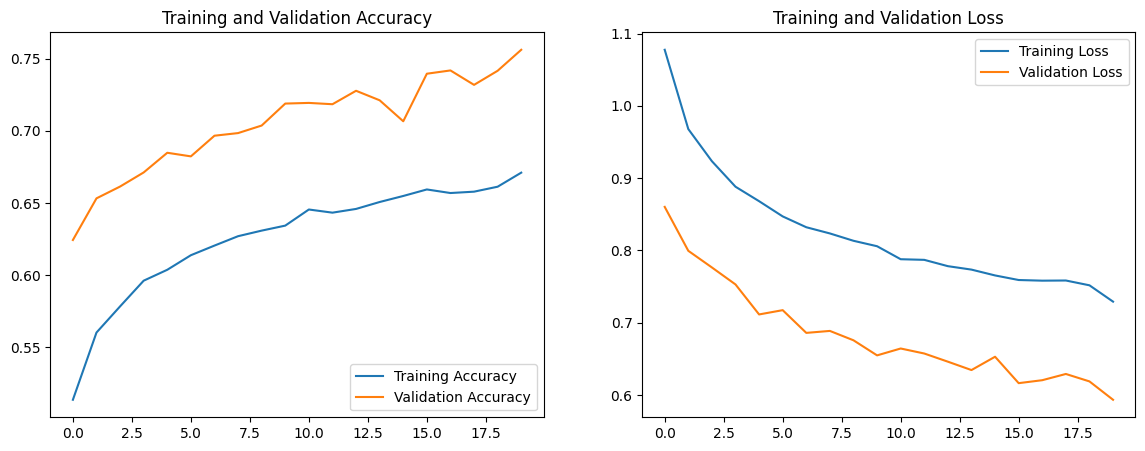

In [19]:
import matplotlib.pyplot as plt

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plotting Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

###Model Evaluation: Confusion Matrix

In medical diagnostic models, overall accuracy is an insufficient metric, particularly when differentiating between visually similar stages like "NonDemented" and "VeryMildDemented." This section evaluates the model's granular performance.

* **Inference Execution:** We iterate through the isolated `val_dataset` batch-by-batch to extract the ground-truth labels and generate prediction probabilities using our trained ResNet50 model.
* **Classification Report:** We calculate the Precision, Recall, and F1-Score for each distinct class. This highlights the model's specific sensitivity and specificity, revealing exactly which Alzheimer's stages the network classifies confidently and which it struggles with.
* **Confusion Matrix:** Utilizing `seaborn`, we map the model's predictions against the true labels in a heatmap format. This provides a direct, visual representation of false positives and false negatives, allowing us to pinpoint the exact intersections where the model's feature extraction is succeeding or failing.

Gathering predictions for evaluation metrics...

--- Classification Report ---
                  precision    recall  f1-score   support

    MildDemented       0.73      0.75      0.74      1033
ModerateDemented       0.95      0.99      0.97      1020
     NonDemented       0.70      0.76      0.73      1264
VeryMildDemented       0.62      0.53      0.57      1083

        accuracy                           0.75      4400
       macro avg       0.75      0.76      0.75      4400
    weighted avg       0.75      0.75      0.75      4400



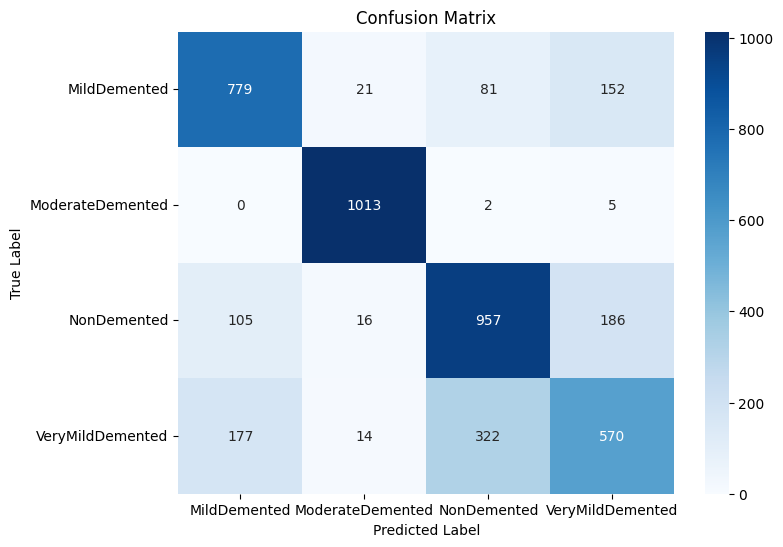

In [20]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Extract true labels and images from the validation dataset
y_true = []
y_pred_probs = []

print("Gathering predictions for evaluation metrics...")
for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



###Multi-class ROC Curve & AUC Analysis

While a Confusion Matrix provides a static snapshot of model performance at a default threshold, it does not show how confident the model is in its predictions. To evaluate the model's diagnostic capability across all possible classification thresholds, we generate a Receiver Operating Characteristic (ROC) curve.

* **What is ROC?** The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity). Because ROC is inherently a binary evaluation metric, we utilize `label_binarize` to evaluate our 4-class problem using a "One-vs-Rest" strategy (e.g., "MildDemented" vs. "Everything Else").
* **What is AUC?** The Area Under the Curve (AUC) condenses the ROC curve into a single metric from 0.0 to 1.0. An AUC of 0.50 (the black dotted diagonal line) represents a model that is randomly guessing. An AUC of 1.0 represents a perfect diagnostic model.
* **Interpreting the Graph:** * The ideal model curves sharply toward the top-left corner, maximizing True Positives while keeping False Positives near zero.
  * By plotting all four classes on the same axes, we can visually diagnose the model's specific blind spots. For instance, if the AUC for "NonDemented" and "VeryMildDemented" is noticeably lower than "ModerateDemented," it mathematically proves that the neural network struggles primarily with the microscopic variances between healthy brains and early-stage cognitive decline.

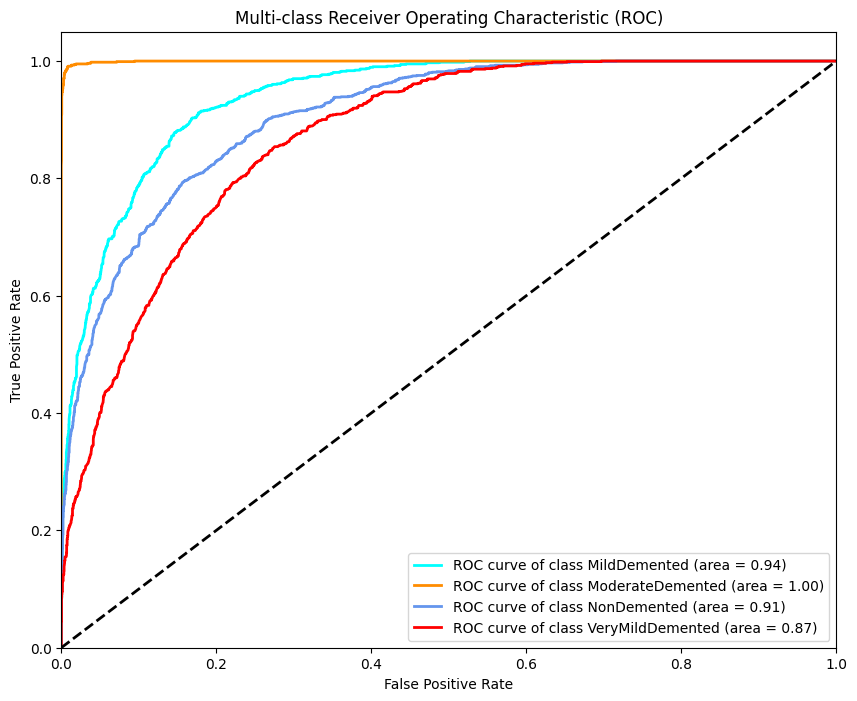

In [21]:
# 4. Multi-class ROC Curve
# Binarize the true labels for the ROC calculation
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (area = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()